# **Klasifikasi dengan ektraksi fitur menggunakan  Latent Dirichlet Allocation Menggunakan Model Naive bayes dan SVM**

In [ ]:
!pip install gensim

In [ ]:
!pip install gensim matplotlib seaborn scikit-learn pandas numpy

In [ ]:
!pip install umap-learn

In [ ]:
import pandas as pd
import numpy as np
import gensim
from gensim import corpora, models
from gensim.models.ldamodel import LdaModel
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Baca data
df_path = "/content/drive/MyDrive/Uts_ppw/Berita.csv"
df = pd.read_csv(df_path)

# Cek kolom
df.head()

,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...


In [ ]:
# Melihat daftar kategori unik
print(df['kategori'].unique())

# Menghitung jumlah kategori unik
print("Jumlah kategori:", df['kategori'].nunique())

# Kalau mau lihat jumlah data per kategori
print(df['kategori'].value_counts())

['Ekonomi' 'Olahraga' 'Nasional' 'Internasional']
Jumlah kategori: 4
kategori
Ekonomi          375
Olahraga         375
Nasional         375
Internasional    375
Name: count, dtype: int64


In [ ]:
# Cek jumlah NaN di tiap kolom
print(df.isna().sum())

No          0
judul       0
berita      0
tanggal     0
kategori    0
link        0
dtype: int64


In [ ]:
# Hapus baris yang abstrak_en kosong
data = df.dropna(subset=['berita']).reset_index(drop=True)

# Cek lagi apakah masih ada yang kosong
print(data['berita'].isna().sum())


0


In [ ]:
data

,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
...,...,...,...,...,...,...
1495,1496,Laporan Sebab Tabrakan Pesawat-Black Hawk Dita...,Anggota Dewan Keselamatan Transportasi Nasiona...,"Jumat, 31 Jan 2025 04:40 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1496,1497,"Israel Bebaskan 110 Sandera Palestina, Diantar...",Israel telah membebaskan 110 tahanan Palestina...,"Jumat, 31 Jan 2025 03:01 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1497,1498,Hamas Konfirmasi Kematian Komandan Al Qassam M...,Hamas mengonfirmasi kematian kepala militernya...,"Jumat, 31 Jan 2025 02:30 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1498,1499,Black Box American Airlines Ditemukan Usai Tab...,Tim penyelam diduga menemukan satu dari dua bl...,"Jumat, 31 Jan 2025 01:00 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...


#Cleaning data

In [ ]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                         # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)        # hilangkan angka/simbol
    text = re.sub(r'\s+', ' ', text).strip()        # hilangkan spasi berlebih
    return text

# Terapkan cleansing
data['cleaned'] = data['berita'].apply(cleansing)

# Simpan ke CSV
data.to_csv('/content/drive/MyDrive/Uts_ppw/isi_berita_cleaned.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
data[['berita','cleaned']].head()

Data berhasil disimpan ke CSV!



,berita,cleaned
0,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...
2,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...


In [ ]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 43.4 MB/s eta 0:00:00


#Stopword

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat stopword remover
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

# Terapkan stopword removal pada kolom 'cleaned'
data['no_stopwords'] = data['cleaned'].apply(stopword.remove)

# Simpan hasil ke CSV
data.to_csv('/content/drive/MyDrive/Uts_ppw/berita_cnn_no_stopwords.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
data[['cleaned','no_stopwords']].head()


Data berhasil disimpan ke CSV!



,cleaned,no_stopwords
0,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...
1,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...
2,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...
3,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...
4,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...


#Stemming

In [ ]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords'
data['stemmed'] = data['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV
data.to_csv('/content/drive/MyDrive/Uts_ppw/berita_cnn_stemmed.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
data[['no_stopwords','stemmed']].head()


Data berhasil disimpan ke CSV!



,no_stopwords,stemmed
0,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...
1,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...
2,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...
3,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...
4,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...


# Tokenisasi

In [ ]:
import pandas as pd

# Fungsi tokenisasi sederhana
def tokenize(text):
    return text.split()

# Terapkan tokenisasi pada kolom 'stemmed'
data['tokens'] = data['stemmed'].apply(tokenize)

# Simpan hasil ke CSV
data.to_csv('/content/drive/MyDrive/Uts_ppw/berita_cnn_tokens.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
data[['stemmed','tokens']].head()


Data berhasil disimpan ke CSV!



,stemmed,tokens
0,menteri koordinator menko bidang ekonomi airla...,"[menteri, koordinator, menko, bidang, ekonomi,..."
1,rangka riah hari jadi pt surabaya industrial e...,"[rangka, riah, hari, jadi, pt, surabaya, indus..."
2,wacana presiden prabowo subianto bentuk bentuk...,"[wacana, presiden, prabowo, subianto, bentuk, ..."
3,bpjs ketenagakerjaan menteri agama kemenag ber...,"[bpjs, ketenagakerjaan, menteri, agama, kemena..."
4,perintah segera bentuk satu tugas putus hubung...,"[perintah, segera, bentuk, satu, tugas, putus,..."


In [ ]:
# Baca data
df_path1 = "/content/drive/MyDrive/Uts_ppw/berita_cnn_tokens.csv"
df_berita = pd.read_csv(df_path1)

# Cek kolom
df_berita.head()

,No,judul,berita,tanggal,kategori,link,cleaned,no_stopwords,stemmed,tokens
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...,"['menteri', 'koordinator', 'menko', 'bidang', ..."
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...,"['rangka', 'riah', 'hari', 'jadi', 'pt', 'sura..."
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...,"['wacana', 'presiden', 'prabowo', 'subianto', ..."
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...,"['bpjs', 'ketenagakerjaan', 'menteri', 'agama'..."
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...,"['perintah', 'segera', 'bentuk', 'satu', 'tuga..."


In [ ]:
df_berita[['kategori', 'stemmed']].head()

,kategori,stemmed
0,Ekonomi,menteri koordinator menko bidang ekonomi airla...
1,Ekonomi,rangka riah hari jadi pt surabaya industrial e...
2,Ekonomi,wacana presiden prabowo subianto bentuk bentuk...
3,Ekonomi,bpjs ketenagakerjaan menteri agama kemenag ber...
4,Ekonomi,perintah segera bentuk satu tugas putus hubung...


In [ ]:
# Melihat daftar kategori unik
print(df_berita['kategori'].unique())

# Menghitung jumlah kategori unik
print("Jumlah kategori:", df['kategori'].nunique())

# Kalau mau lihat jumlah data per kategori
print(df_berita['kategori'].value_counts())

['Ekonomi' 'Olahraga' 'Nasional' 'Internasional']
Jumlah kategori: 4
kategori
Ekonomi          375
Olahraga         375
Nasional         375
Internasional    375
Name: count, dtype: int64


## **Siapkan data untuk LDA**

In [ ]:
# Ubah string list token menjadi list Python
import ast
df_berita['tokens'] = df_berita['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Buat kamus (dictionary) dan corpus untuk Gensim
dictionary = corpora.Dictionary(df_berita['tokens'])
corpus = [dictionary.doc2bow(text) for text in df_berita['tokens']]

print("Jumlah dokumen:", len(corpus))
print("Jumlah kata unik:", len(dictionary))

Jumlah dokumen: 1500
Jumlah kata unik: 18463


## **Training Model LDA**

In [ ]:
# Tentukan jumlah topik (bisa kamu sesuaikan)
num_topics = 10

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False):
    print(f"\nTopik {i+1}:")
    print(", ".join([word for word, prob in topic]))




Topik 1:
indonesia, main, timnas, piala, jadi, latih, gol, menit, menang, laga

Topik 2:
israel, senjata, gaza, gencat, bakar, hamas, kata, palestina, sebut, orang

Topik 3:
orang, kata, jadi, sebut, suriah, banjir, al, air, warga, pesawat

Topik 4:
program, kata, makan, gizi, jalan, jadi, jakarta, gratis, mbg, anak

Topik 5:
yoon, presiden, kpk, kata, sebut, korupsi, militer, negara, darurat, makzul

Topik 6:
sebut, kata, prabowo, presiden, jadi, negara, kerja, laku, undang, perintah

Topik 7:
laku, duga, sebut, kasus, kata, hasto, kpk, korban, sangka, periksa

Topik 8:
laut, pagar, sebut, kata, menteri, tangerang, ada, milik, nelayan, bangun

Topik 9:
kata, negara, jadi, sebut, indonesia, as, trump, menteri, presiden, rusia

Topik 10:
rp, persen, jadi, tahun, indonesia, menteri, harga, kata, besar, perintah


## **Ubah hasil LDA menjadi fitur numerik**

In [ ]:
def get_topic_distribution(lda_model, corpus):
    topic_features = []
    for doc in corpus:
        topic_dist = [0] * lda_model.num_topics
        for topic_num, prob in lda_model.get_document_topics(doc):
            topic_dist[topic_num] = prob
        topic_features.append(topic_dist)
    return np.array(topic_features)

X_lda = get_topic_distribution(lda_model, corpus)
y = df_berita['kategori']

print("Ekstraksi fitur LDA selesai.")
X_lda.shape

Ekstraksi fitur LDA selesai.


(1500, 10)

In [ ]:
# Gabungkan hasil LDA dengan kategori berita
df_lda = pd.DataFrame(X_lda, columns=[f"Topik_{i+1}" for i in range(X_lda.shape[1])])
df_lda['kategori'] = df_berita['kategori'].values

# Lihat 5 baris pertama
df_lda.head()


,Topik_1,Topik_2,Topik_3,Topik_4,Topik_5,Topik_6,Topik_7,Topik_8,Topik_9,Topik_10,kategori
0,0.0,0.000000,0.0,0.000000,0.191518,0.000000,0.0,0.0,0.000000,0.807348,Ekonomi
1,0.0,0.444268,0.0,0.298156,0.000000,0.000000,0.0,0.0,0.000000,0.247429,Ekonomi
2,0.0,0.000000,0.0,0.000000,0.000000,0.080748,0.0,0.0,0.507695,0.410428,Ekonomi
3,0.0,0.000000,0.0,0.000000,0.000000,0.938369,0.0,0.0,0.000000,0.059917,Ekonomi
4,0.0,0.000000,0.0,0.000000,0.467736,0.000000,0.0,0.0,0.022657,0.508351,Ekonomi


## **Bagi Data Train dan Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Jumlah data latih: {len(X_train)}, data uji: {len(X_test)}")


Jumlah data latih: 1200, data uji: 300


## **Klasifikasi SVM**

In [ ]:
svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train, y_train)

print("Model SVM berhasil dilatih dengan fitur hasil ekstraksi LDA.")

Model SVM berhasil dilatih dengan fitur hasil ekstraksi LDA.


## **Evaluasi Model**

In [ ]:
y_pred = svm_model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi Model: 0.8766666666666667

Laporan Klasifikasi:
                precision    recall  f1-score   support

      Ekonomi       0.84      0.88      0.86        75
Internasional       0.83      0.91      0.87        75
     Nasional       0.85      0.73      0.79        75
     Olahraga       1.00      0.99      0.99        75

     accuracy                           0.88       300
    macro avg       0.88      0.88      0.88       300
 weighted avg       0.88      0.88      0.88       300



## **Visualisasi Confusion Matrix**

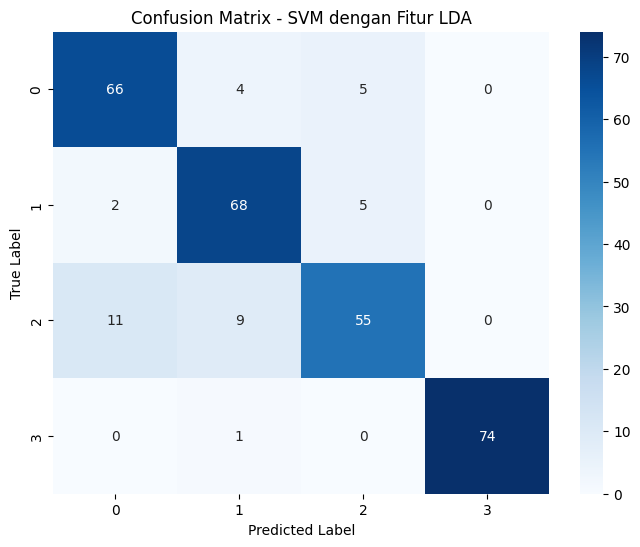

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM dengan Fitur LDA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## **Distribusi Topik per Kategori**

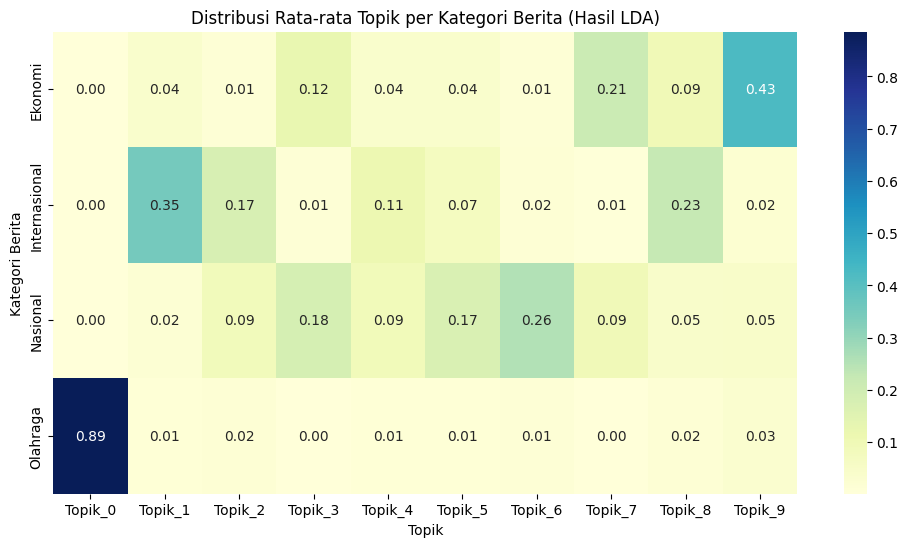

In [ ]:
topic_df = pd.DataFrame(X_lda, columns=[f"Topik_{i}" for i in range(num_topics)])
topic_df["Kategori"] = y.values

topic_by_category = topic_df.groupby("Kategori").mean()

plt.figure(figsize=(12,6))
sns.heatmap(topic_by_category, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Distribusi Rata-rata Topik per Kategori Berita (Hasil LDA)")
plt.xlabel("Topik")
plt.ylabel("Kategori Berita")
plt.show()


## **Topik Dominan per Dokumen**

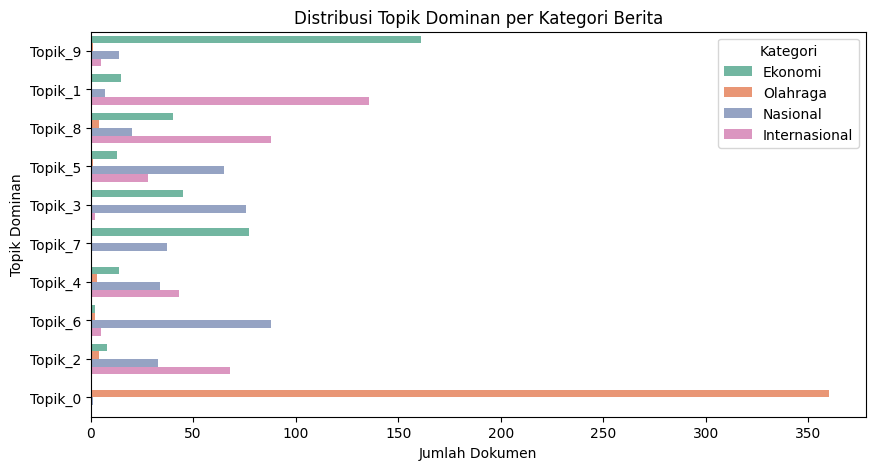

In [ ]:
topic_df["Topik_Dominan"] = topic_df[[f"Topik_{i}" for i in range(num_topics)]].idxmax(axis=1)

plt.figure(figsize=(10,5))
sns.countplot(y="Topik_Dominan", hue="Kategori", data=topic_df, palette="Set2")
plt.title("Distribusi Topik Dominan per Kategori Berita")
plt.xlabel("Jumlah Dokumen")
plt.ylabel("Topik Dominan")
plt.legend(title="Kategori")
plt.show()


## **Proyeksi 2D Data LDA**

In [ ]:
import umap
# Buat model UMAP
umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42)

# Fit-transform untuk data training dan test
X_train_2d = umap_model.fit_transform(X_train)
X_test_2d = umap_model.transform(X_test)

# Simpan hasil proyeksi ke DataFrame
train_umap = pd.DataFrame(X_train_2d, columns=['x', 'y'])
train_umap['Kategori'] = y_train.values

test_umap = pd.DataFrame(X_test_2d, columns=['x', 'y'])
test_umap['Kategori'] = y_test.values


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## **Visualisasi**

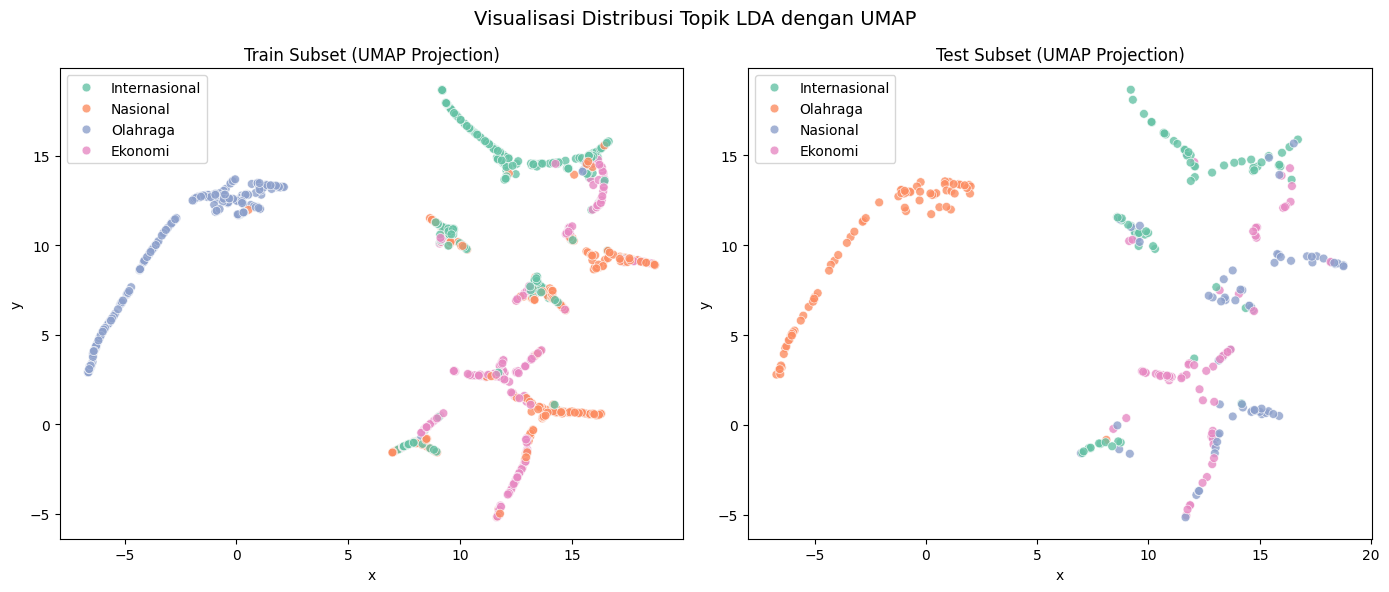

In [ ]:
plt.figure(figsize=(14,6))

# Plot subset training
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=train_umap,
    x='x', y='y',
    hue='Kategori',
    palette='Set2',
    s=40,
    alpha=0.8
)
plt.title('Train Subset (UMAP Projection)')
plt.legend(loc='best')

# Plot subset testing
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=test_umap,
    x='x', y='y',
    hue='Kategori',
    palette='Set2',
    s=40,
    alpha=0.8
)
plt.title('Test Subset (UMAP Projection)')
plt.legend(loc='best')

plt.suptitle('Visualisasi Distribusi Topik LDA dengan UMAP', fontsize=14)
plt.tight_layout()
plt.show()


#Klasifikasi Naive bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Accuracy (Naive Bayes): 0.8633333333333333
               precision    recall  f1-score   support

      Ekonomi       0.81      0.87      0.84        75
Internasional       0.81      0.88      0.85        75
     Nasional       0.83      0.72      0.77        75
     Olahraga       1.00      0.99      0.99        75

     accuracy                           0.86       300
    macro avg       0.86      0.86      0.86       300
 weighted avg       0.86      0.86      0.86       300



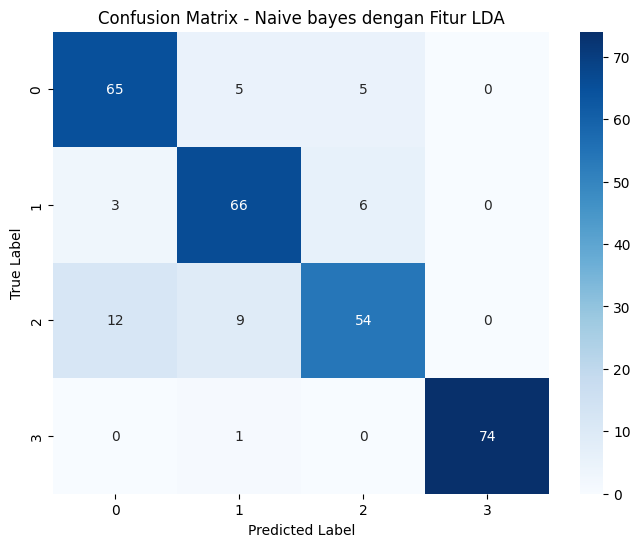

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Naive bayes dengan Fitur LDA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Clustering Email

In [ ]:
# Baca data
df_path_email = "/content/drive/MyDrive/Uts_ppw/spam.csv"
df_email = pd.read_csv(df_path_email, encoding='windows-1252')

# Cek kolom
df_email.head()

,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Melihat daftar kategori unik
print(df_email['Text'].unique())

# Menghitung jumlah Text unik
print("Jumlah Text:", df_email['Text'].nunique())

# Kalau mau lihat jumlah data per Text
print(df_email['Text'].value_counts())

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 ... 'Pity, * was in mood for that. So...any other suggestions?'
 "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
 'Rofl. Its true to its name']
Jumlah Text: 5169
Text
Sorry, I'll call later                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                    12
Ok...                                                                                                    

In [ ]:
# Cek jumlah NaN di tiap kolom
print(df_email.isna().sum())

id               0
Text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [ ]:
# Hapus kolom kosong (yang tidak diperlukan)
df_email = df_email.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

# Hapus baris yang kolom 'Text'-nya kosong
df_email = df_email.dropna(subset=['Text']).reset_index(drop=True)

# Cek hasil
print("Jumlah data setelah dibersihkan:", df_email.shape)
print(df_email.isna().sum())
df_email.head()


Jumlah data setelah dibersihkan: (5572, 2)
id      0
Text    0
dtype: int64


,id,Text
0,1,"Go until jurong point, crazy.. Available only ..."
1,2,Ok lar... Joking wif u oni...
2,3,Free entry in 2 a wkly comp to win FA Cup fina...
3,4,U dun say so early hor... U c already then say...
4,5,"Nah I don't think he goes to usf, he lives aro..."


#Cleaning data

In [ ]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                         # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)        # hilangkan angka/simbol
    text = re.sub(r'\s+', ' ', text).strip()        # hilangkan spasi berlebih
    return text

# Terapkan cleansing
df_email['cleaned'] = df_email['Text'].apply(cleansing)

# Simpan ke CSV
df_email.to_csv('/content/drive/MyDrive/Uts_ppw/isi_email_cleaned.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
df_email[['Text','cleaned']].head()

Data berhasil disimpan ke CSV!



,Text,cleaned
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [ ]:
!pip install pyspellchecker

#Stopword

In [ ]:
!pip install Sastrawi

In [ ]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat stopword remover
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

# Terapkan stopword removal pada kolom 'cleaned'
df_email['no_stopwords'] = df_email['cleaned'].apply(stopword.remove)

# Simpan hasil ke CSV
df_email.to_csv('/content/drive/MyDrive/Uts_ppw/email_stopwords.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
df_email[['cleaned','no_stopwords']].head()


Data berhasil disimpan ke CSV!



,cleaned,no_stopwords
0,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...
1,ok lar joking wif u oni,lar joking wif u oni
2,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...
3,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...


#Stemming

In [80]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords'
df_email['stemmed'] = df_email['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV
df_email.to_csv('/content/drive/MyDrive/Uts_ppw/email_stemmed.csv', index=False)
print("data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
df_email[['no_stopwords','stemmed']].head()


data berhasil disimpan ke CSV!



,no_stopwords,stemmed
0,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...
1,lar joking wif u oni,lar joking wif u oni
2,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...
3,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...


#Tokenisasi

In [81]:
import pandas as pd

# Fungsi tokenisasi sederhana
def tokenize(text):
    return text.split()

# Terapkan tokenisasi pada kolom 'stemmed'
df_email['tokens'] = df_email['stemmed'].apply(tokenize)

# Simpan hasil ke CSV
df_email.to_csv('/content/drive/MyDrive/Uts_ppw/email_tokens.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
df_email[['stemmed','tokens']].head()


Data berhasil disimpan ke CSV!



,stemmed,tokens
0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,lar joking wif u oni,"[lar, joking, wif, u, oni]"
2,free entry in a wkly comp to win fa cup final ...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,nah i don t think he goes to usf he lives arou...,"[nah, i, don, t, think, he, goes, to, usf, he,..."


In [85]:
# Baca data
df_path2 = "/content/drive/MyDrive/Uts_ppw/email_tokens.csv"
df_email = pd.read_csv(df_path2)

# Cek kolom
df_email.head()

,id,Text,cleaned,no_stopwords,stemmed,tokens
0,1,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...,"['go', 'until', 'jurong', 'point', 'crazy', 'a..."
1,2,Ok lar... Joking wif u oni...,ok lar joking wif u oni,lar joking wif u oni,lar joking wif u oni,"['lar', 'joking', 'wif', 'u', 'oni']"
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...,"['free', 'entry', 'in', 'a', 'wkly', 'comp', '..."
3,4,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,u dun say so early hor u c already then say,u dun say so early hor u c already then say,"['u', 'dun', 'say', 'so', 'early', 'hor', 'u',..."
4,5,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...,"['nah', 'i', 'don', 't', 'think', 'he', 'goes'..."


In [87]:
df_email[['Text', 'stemmed']].head()

,Text,stemmed
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [90]:
# Melihat daftar Text unik
print(df_email['Text'].unique())

# Menghitung jumlah Text unik
print("Jumlah Text:", df_email['Text'].nunique())

# Kalau mau lihat jumlah data per Text
print(df_email['Text'].value_counts())

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 ... 'Pity, * was in mood for that. So...any other suggestions?'
 "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
 'Rofl. Its true to its name']
Jumlah Text: 5169
Text
Sorry, I'll call later                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                    12
Ok...                                                                                                    

#LDA

In [91]:
# Ubah string list token menjadi list Python
import ast
df_email['tokens'] = df_email['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Buat kamus (dictionary) dan corpus untuk Gensim
dictionary = corpora.Dictionary(df_email['tokens'])
corpus = [dictionary.doc2bow(text) for text in df_email['tokens']]

print("Jumlah dokumen:", len(corpus))
print("Jumlah kata unik:", len(dictionary))

Jumlah dokumen: 5572
Jumlah kata unik: 7697


In [92]:
# Tentukan jumlah topik (bisa kamu sesuaikan)
num_topics = 10

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False):
    print(f"\nTopik {i+1}:")
    print(", ".join([word for word, prob in topic]))




Topik 1:
to, ur, a, is, u, now, the, p, only, have

Topik 2:
to, free, call, txt, for, or, a, your, now, reply

Topik 3:
u, of, a, the, is, in, me, d, r, hi

Topik 4:
u, i, face, d, no, thats, its, msg, chikku, sent

Topik 5:
you, are, i, my, how, a, good, love, day, hope

Topik 6:
u, i, lor, da, go, then, me, now, wat, in

Topik 7:
your, the, to, for, is, pls, send, no, message, free

Topik 8:
gt, lt, i, the, sorry, of, s, she, in, is

Topik 9:
i, you, to, and, a, the, it, me, in, that

Topik 10:
call, a, to, you, from, your, have, prize, urgent, please


#ubah LDA menjadi numeric

In [93]:
def get_topic_distribution(lda_model, corpus):
    topic_features = []
    for doc in corpus:
        topic_dist = [0] * lda_model.num_topics
        for topic_num, prob in lda_model.get_document_topics(doc):
            topic_dist[topic_num] = prob
        topic_features.append(topic_dist)
    return np.array(topic_features)

X_lda = get_topic_distribution(lda_model, corpus)
y = df_email['Text']

print("Ekstraksi fitur LDA selesai.")
X_lda.shape

Ekstraksi fitur LDA selesai.


(5572, 10)

In [95]:
# Gabungkan hasil LDA dengan kategori berita
df_ida_email = pd.DataFrame(X_lda, columns=[f"Topik_{i+1}" for i in range(X_lda.shape[1])])
df_ida_email['Text'] = df_email['Text'].values

# Lihat 5 baris pertama
df_ida_email.head()


,Topik_1,Topik_2,Topik_3,Topik_4,Topik_5,Topik_6,Topik_7,Topik_8,Topik_9,Topik_10,Text
0,0.0,0.000000,0.000000,0.0,0.045113,0.822026,0.000000,0.000000,0.113002,0.0,"Go until jurong point, crazy.. Available only ..."
1,0.0,0.010647,0.012383,0.0,0.350913,0.524103,0.010184,0.012838,0.054704,0.0,Ok lar... Joking wif u oni...
2,0.0,0.971756,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.011497,0.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0.0,0.000000,0.122388,0.0,0.000000,0.815120,0.000000,0.000000,0.027787,0.0,U dun say so early hor... U c already then say...
4,0.0,0.000000,0.000000,0.0,0.071883,0.000000,0.081670,0.000000,0.816306,0.0,"Nah I don't think he goes to usf, he lives aro..."


#Model clustering

Silhouette Score: 0.4801

 Cluster 0
 I‰Û÷m going to try for 2 months ha ha only joking
Did you catch the bus ? Are you frying an egg ?...
Do you know what Mallika Sherawat did yesterday...

 Cluster 1
Nah I don't think he goes to usf, he lives arou...
FreeMsg Hey there darling it's been 3 week's no...
Even my brother is not like to speak with me. T...

 Cluster 2
Go until jurong point, crazy.. Available only i...
                     Ok lar... Joking wif u oni...
 U dun say so early hor... U c already then say...

 Cluster 3
                               WHO ARE YOU SEEING?
Today is \song dedicated day..\" Which song wil...
                         First answer my question.

 Cluster 4
England v Macedonia - dont miss the goals/team ...
Congrats! 1 year special cinema pass for 2 is y...
         Ela kano.,il download, come wen ur free..

 Cluster 5
As per your request 'Melle Melle (Oru Minnaminu...
Had your mobile 11 months or more? U R entitled...
         Is that seriously how you s

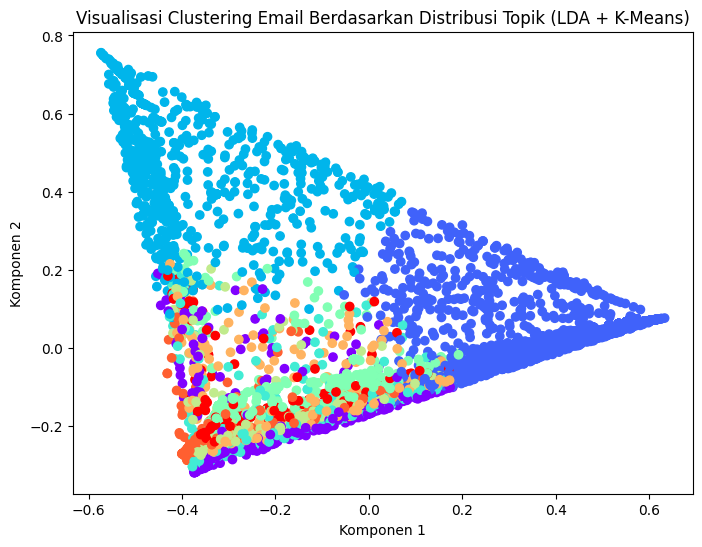

In [106]:

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 2. Siapkan Data Hasil LDA
# Asumsinya kamu sudah punya: X_lda dan df_email
df_lda_email = pd.DataFrame(X_lda, columns=[f"Topik_{i+1}" for i in range(X_lda.shape[1])])
df_lda_email['Text'] = df_email['Text'].values

# 3. Clustering dengan K-Means Berdasarkan Distribusi Topik
num_clusters = 9 # jumlah cluster bisa kamu sesuaikan (misal: 3–8)
kmeans_lda = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans_lda.fit(X_lda)

# Simpan hasil cluster ke DataFrame
df_lda_email['Cluster'] = kmeans_lda.labels_

# 4. Evaluasi Clustering
sil_score = silhouette_score(X_lda, kmeans_lda.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

# 5. Contoh Isi Tiap Cluster
for i in range(num_clusters):
    print(f"\n Cluster {i}")
    print(df_lda_email[df_lda_email['Cluster'] == i]['Text'].head(3).to_string(index=False))

# 6. Visualisasi Distribusi Cluster (2D dengan PCA)
pca = PCA(n_components=2, random_state=42)
reduced_X = pca.fit_transform(X_lda)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_X[:, 0], reduced_X[:, 1], c=df_lda_email['Cluster'], cmap='rainbow')
plt.title('Visualisasi Clustering Email Berdasarkan Distribusi Topik (LDA + K-Means)')
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.show()


[Lanjut ke dataset_nasajuli](dataset_nasajuli.ipynb)
